In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing CSV File
df = pd.read_csv('https://raw.githubusercontent.com/MohammedAyanSyed/projects/refs/heads/main/End-to-End%20Apps/Ride_Cancellation/data/df_cleaned.csv')

In [3]:
# Converting Data-Types
df['date'] = pd.to_datetime(df['date'],format='%Y-%m-%d')
df['time'] = pd.to_datetime(df['time'],format='%H:%M:%S')

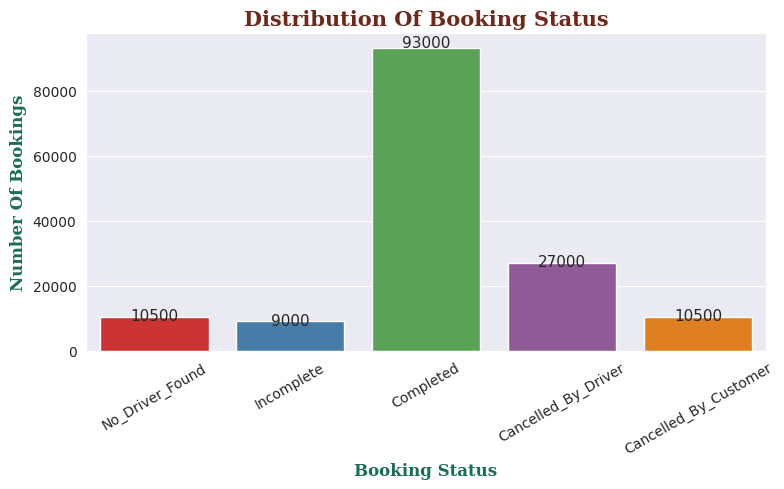

In [4]:
# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('darkgrid')

# Countplot
ax = sns.countplot(x='booking_status',data=df,hue='booking_status',palette='Set1')

# Annotation
for i in ax.patches:
    length = i.get_height()
    if length > 0:
        plt.text(i.get_x()+i.get_width()/2,length*1.02,round(length),ha='center',va='center',fontsize=11)

# Styling Title and Labels
plt.title('Distribution Of Booking Status',fontsize=15,fontweight='bold',fontfamily='Serif',color='#6E2718')
plt.xlabel('Booking Status',fontsize=12,fontweight='bold',fontfamily='Serif',color='#186E56')
plt.ylabel('Number Of Bookings',fontsize=12,fontweight='bold',fontfamily='Serif',color='#186E56')
plt.xticks(rotation=30)

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Completed rides holds for the majority of bookins, indicating successful ride fulfillment.
# Cancelled and incomplete rides represent a smaller share, highlighting oppurtunies to reduce servide fulfillment

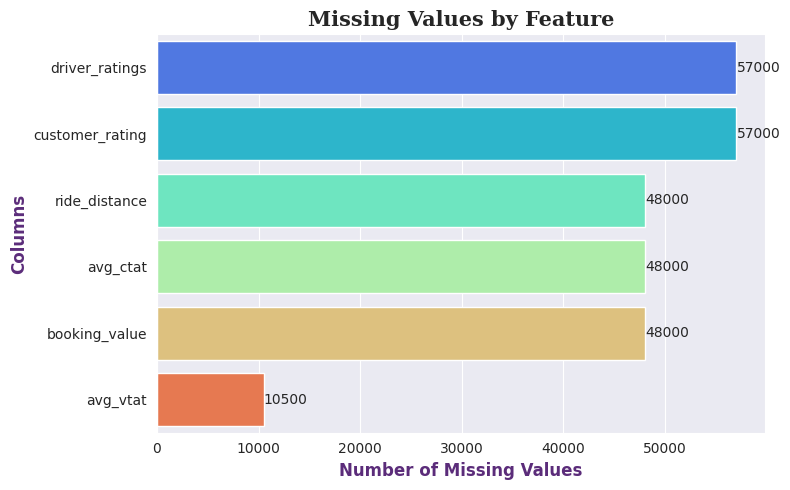

In [5]:
# Null DataFrame
df_null = df.columns[df.isnull().sum()>=1]
df[df_null] = df[df_null].rename(columns={0:'values'})
df_null = df[df_null].isnull().sum().sort_values(ascending=False)
col = df_null.index
val = df_null.values

# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('darkgrid')

# Horizontal Bar Plot
ax = sns.barplot(x=val,y=col,hue=col,palette='rainbow')

# Annotation
for i in ax.patches:
    width = i.get_width()
    if width > 0 :
        plt.text(width*1.001,i.get_y()+i.get_height()/2,round(width),ha='left',va='center')

# Styling Title and Labels
plt.title('Missing Values by Feature',fontweight='bold',fontsize=15,fontfamily='Serif')
plt.xlabel('Number of Missing Values',fontweight='bold',fontsize=12,color='#5B2C7A')
plt.ylabel('Columns',fontweight='bold',fontsize=12,color='#5B2C7A')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Most missing values are concentrated at ride outcome-related features like ratings,price,ride_distace,ctat and vtat rather than
# being randomly distributed.
# Thid indicates that the missing values are driven by the ride lifecycle.

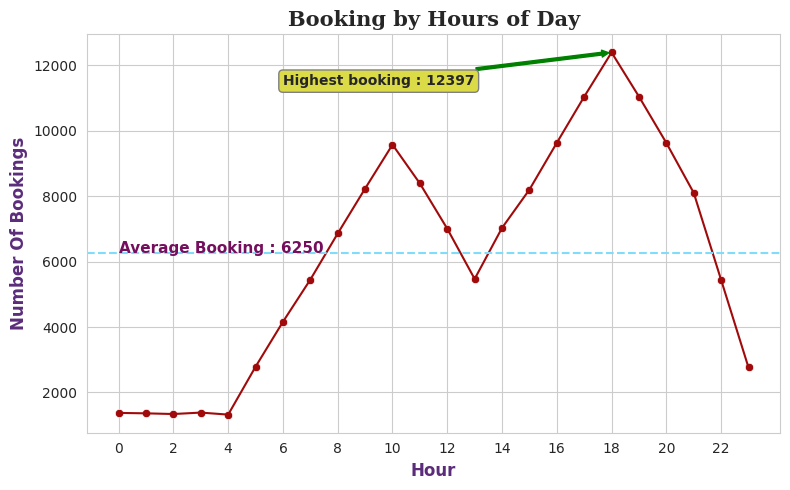

In [7]:
# Group By
hourdis = df.groupby(df['time'].dt.hour)['booking_id'].count().reset_index()

# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('whitegrid')

# Line + Scatter Plot
sns.lineplot(x='time',y='booking_id',data=hourdis,color='#A10A0A')
sns.scatterplot(x='time',y='booking_id',data=hourdis,color='#A10A0A')

# Annotation
max_index = hourdis['booking_id'].argmax()
max_value = hourdis.loc[max_index,'booking_id']
plt.annotate(text=f'Highest booking : {max_value}',xy=(max_index,max_value),xytext=(max_index-12,max_value-1000),
            arrowprops=dict(arrowstyle='simple',color='green'),bbox=dict(boxstyle='round',facecolor='#DBDB48',edgecolor='grey'),
            fontweight='bold')
plt.axhline(hourdis['booking_id'].mean(),linestyle='--',color='#7FDCFA')
plt.annotate(text=f"Average Booking : {round(hourdis['booking_id'].mean())}",xy=(2,hourdis['booking_id'].mean()),xytext=(0,hourdis['booking_id'].mean()),
            fontweight='bold',fontsize=11,color='#750F5D')

# Styling Title and Label
plt.title('Booking by Hours of Day',fontweight='bold',fontsize=15,fontfamily='Serif')
plt.xlabel('Hour',fontweight='bold',fontsize=12,color='#5B2C7A')
plt.ylabel('Number Of Bookings',fontweight='bold',fontsize=12,color='#5B2C7A')
plt.xticks(range(0,23,2))

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Booking demand varies significantly throughtout the day, with a clear peak during specific hours, indicating high customer activity.
# These peak periods can help ride providers optimize driver availability and reduce booking delays.

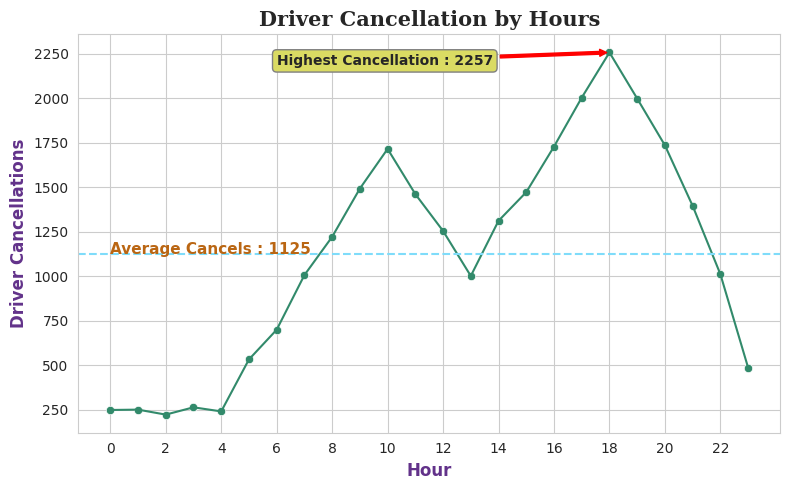

In [10]:
# Group By
cancel_count = df[df['cancelled_rides_by_driver']==1.0].groupby(df['time'].dt.hour)['cancelled_rides_by_driver'].count().reset_index()

# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('whitegrid')

# Line + Scatter plot
sns.lineplot(x='time',y='cancelled_rides_by_driver',data=cancel_count,color='#328A6B')
sns.scatterplot(x='time',y='cancelled_rides_by_driver',data=cancel_count,color='#328A6B')

# Annotation
index = cancel_count['cancelled_rides_by_driver'].argmax()
value = cancel_count.loc[index,'cancelled_rides_by_driver']
plt.annotate(f'Highest Cancellation : {value}',xy=(index,value),xytext=(6,value-70),fontweight='bold',
            arrowprops=dict(arrowstyle='simple',color='red'),
            bbox=dict(boxstyle='round',facecolor='#DADB63',edgecolor='grey'))
plt.axhline(cancel_count['cancelled_rides_by_driver'].mean(),linestyle='--',color='#7FDCFA')
plt.annotate(text=f"Average Cancels : {round(cancel_count['cancelled_rides_by_driver'].mean())}",xy=(2,cancel_count['cancelled_rides_by_driver'].mean()),
             xytext=(0,cancel_count['cancelled_rides_by_driver'].mean()),
            fontweight='bold',fontsize=11,color='#BA6613')

# Styling Title and Labels
plt.title('Driver Cancellation by Hours',fontweight='bold',fontsize=15,fontfamily='Serif')
plt.xlabel('Hour',fontweight='bold',fontsize=12,color='#62328A')
plt.ylabel('Driver Cancellations',fontweight='bold',fontsize=12,color='#62328A')
plt.xticks(range(0,23,2))

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Driver cancellations are concenrated during same specific hours as ride bookings hours
# Understanding these peak cancellation hours

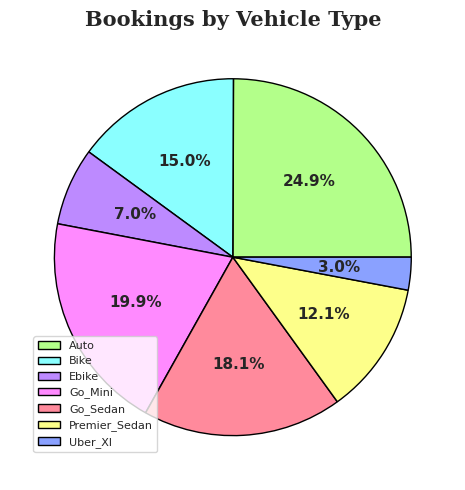

In [11]:
# Group By
veh_type = df.groupby('vehicle_type')['booking_id'].count().reset_index()

# Figure Size
plt.figure(figsize=(8,5))

# Pie Chart
plt.pie(x='booking_id',data=veh_type,explode=[0.001 for i in veh_type['vehicle_type']],
        autopct='%1.1f%%',colors=['#B3FF8A','#8AFFFF','#BD8AFF','#FF8AFF','#FF8A9C','#FDFF8A','#8AA1FF'],
        wedgeprops=dict(edgecolor='k'),pctdistance=0.6,textprops=dict(fontsize=11,fontweight='bold'))

# Styling Title and Legend
plt.legend(veh_type['vehicle_type'],fontsize=8,bbox_to_anchor=(0.04,0.05),loc='lower left')
plt.title('Bookings by Vehicle Type',fontweight='bold',fontsize=15,fontfamily='Serif')

# Page Layout
plt.tight_layout()
plt.show()

# Insights :
# Auto and Go mini account for the largest share of bookings,incidating higher customer preference for these vehicle caegories
# Understanding vehicle demand distribution can help for improving ride availability.

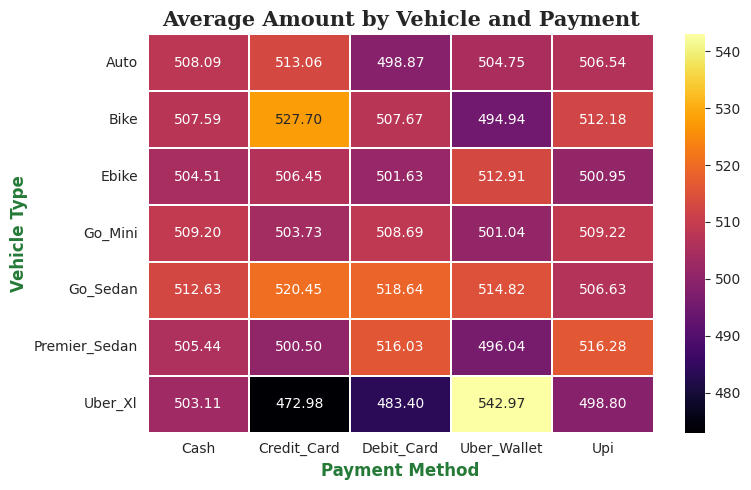

In [12]:
# Pivot Table
we = pd.pivot_table(data=df,index='vehicle_type',columns='payment_method',values='booking_value',aggfunc='mean')

# Figure Size
plt.figure(figsize=(8,5))

# Heatmap
sns.heatmap(we,annot=True,fmt='.2f',cmap='inferno',linewidth=0.1)

# Styling Title and Label
plt.title('Average Amount by Vehicle and Payment',fontweight='bold',fontsize=15,fontfamily='Serif')
plt.xlabel('Payment Method',fontweight='bold',fontsize=12,color='#257A37')
plt.ylabel('Vehicle Type',fontweight='bold',fontsize=12,color='#257A37')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Average booking values vary across vehicle types and payment methods, indicating different customer spending patterns.
# This analysis helps identify which payment methods are associated with higher-value bookings for each vehicle category.

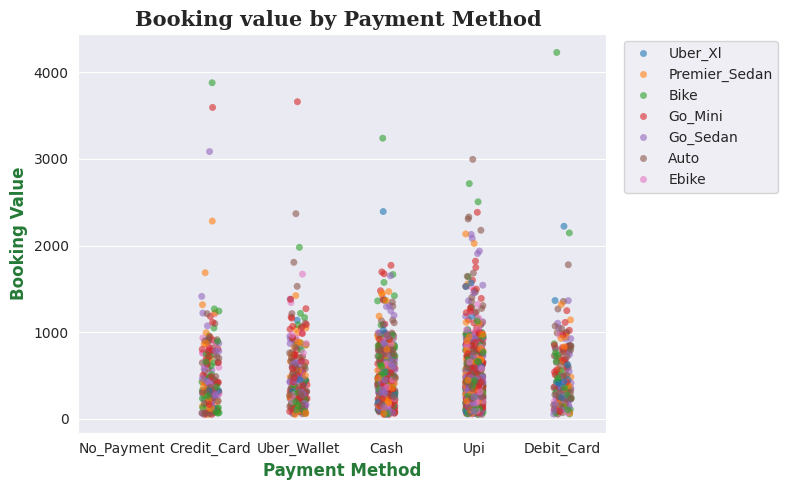

In [13]:
# Sampling
sample_df = df.sample(n=3000,random_state=32)

# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('darkgrid')

# Stripplot
sns.stripplot(x='payment_method',y='booking_value',data=sample_df,hue='vehicle_type',alpha=0.6)

# Styling Title and Labels
plt.title('Booking value by Payment Method ',fontweight='bold',fontsize=15,fontfamily='Serif')
plt.xlabel('Payment Method',fontweight='bold',fontsize=12,color='#257A37')
plt.ylabel('Booking Value',fontweight='bold',fontsize=12,color='#257A37')
plt.legend(bbox_to_anchor=(1.02,1),loc='upper left')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Booking values vary across payment methods, but there is considerable overlap.
# Most booking values are concentrated within a similar range regardless of payment method

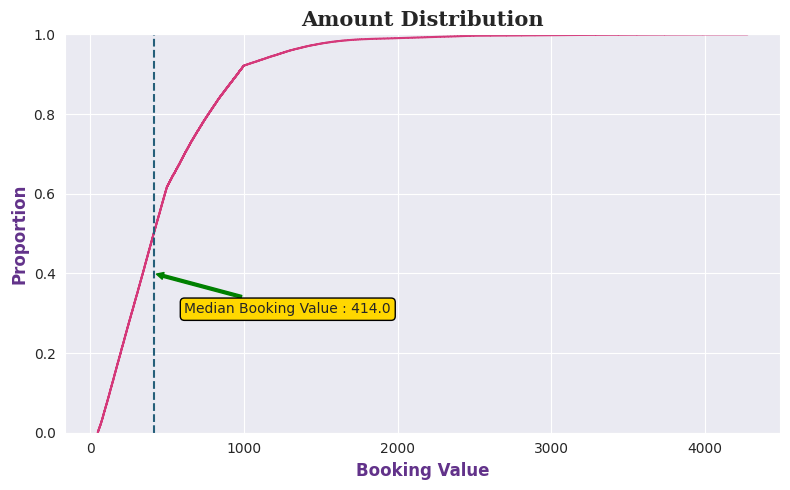

In [14]:
# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('darkgrid')

# ECDF Plot
sns.ecdfplot(x='booking_value',data=df,color='#D4397A')

# Annotation
med = df['booking_value'].median()
plt.axvline(x=med,linestyle='--',color='#255F7A')
plt.annotate(f'Median Booking Value : {med}',xy=(med,0.4),xytext=(med+200,0.3),arrowprops=dict(arrowstyle='simple',color='green'),
            bbox=dict(boxstyle='round',facecolor='gold',edgecolor='k'))

# Styling Title and Labels
plt.title('Amount Distribution',fontweight='bold',fontsize=15,fontfamily='Serif')
plt.xlabel('Booking Value',fontweight='bold',fontsize=12,color='#62328A')
plt.ylabel('Proportion',fontweight='bold',fontsize=12,color='#62328A')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Approx 50% of bookings have value below then median
# Indicating that most rides fall within a moderate price range

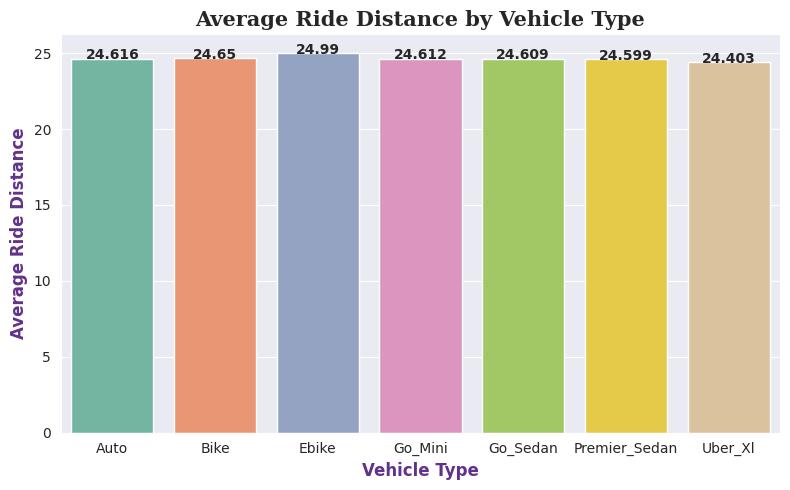

In [15]:
# FE
avg_distance = df.groupby('vehicle_type')['ride_distance'].mean().reset_index()

# Figure Size
plt.figure(figsize=(8,5))

# Page Theme
sns.set_style('darkgrid')

# Barplot
ax = sns.barplot(x='vehicle_type',y='ride_distance',data=avg_distance,hue='vehicle_type',palette='Set2')

# Annotation
for i in ax.patches:
    length = i.get_height()
    if length > 0 :
        plt.text(i.get_x()+i.get_width()/2,i.get_height()*1.01,round(i.get_height(),3),ha='center',va='center',fontweight='bold')

# Styling Title and Lables
plt.title('Average Ride Distance by Vehicle Type',fontweight='bold',fontsize=15,fontfamily='Serif')
plt.xlabel('Vehicle Type',fontweight='bold',fontsize=12,color='#62328A')
plt.ylabel('Average Ride Distance',fontweight='bold',fontsize=12,color='#62328A')

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Vehicle types similar in their average trip distance.
# Indicating that customers prefer any vehicle for longer journeys.

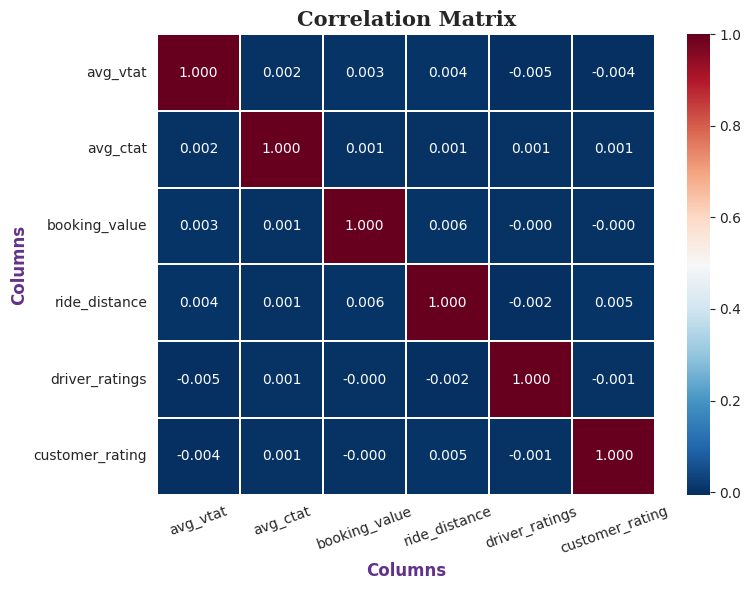

In [16]:
# Feature Engineering
n_df = df.dropna()
n_df = n_df.drop(columns=[col for col in n_df.columns if (n_df[col]==0).all()])
n_cols = n_df.select_dtypes(include=['int','float']).columns.to_list()
cormat = n_df[n_cols].corr()

# Figure Size
plt.figure(figsize=(8,6))

# Heatmap
sns.heatmap(cormat,annot=True,cmap='RdBu_r',fmt='.3f',linewidth=0.01)

# Styling Title and Labels
plt.title('Correlation Matrix',fontweight='bold',fontsize=15,fontfamily='Serif')
plt.xlabel('Columns',fontweight='bold',fontsize=12,color='#62328A')
plt.ylabel('Columns',fontweight='bold',fontsize=12,color='#62328A')
plt.xticks(rotation=20)

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# Most numerical features exhibit weak to moderate correlations
# Indicating limited multicollinearity and suggesting